# Test before create autmation 

Change `USER_ID` in the next cell to inspect a different user. This notebook reads every `Move` and `Drag` point from the selected user's raw session files.

In [20]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

USER_ID = "user7"
OUTPUT_ROOT = Path("../outputs/balabit_training_files_first_movements")
USER_DIR = OUTPUT_ROOT / USER_ID

session_rows = []
for json_path in sorted(USER_DIR.glob("session_*.json")):
    with json_path.open() as handle:
        capture = json.load(handle)

    points = capture.get("points", [])
    for point_index, point in enumerate(points):
        session_rows.append(
            {
                "session_id": json_path.stem,
                "point_index": point_index,
                "timestamp_ms": point["timestamp_ms"],
                "x": point["x"],
                "y": point["y"],
                "event_type": point["event_type"],
                "button": point["button"],
            }
        )

points = pd.DataFrame(session_rows)
if points.empty:
    raise ValueError(f"No movement points found for {USER_ID} in {USER_DIR}")

summary = (
    points.groupby("session_id", as_index=False)
    .agg(
        point_count=("point_index", "size"),
        duration_ms=("timestamp_ms", lambda values: values.max() - values.min()),
        first_x=("x", "first"),
        first_y=("y", "first"),
        last_x=("x", "last"),
        last_y=("y", "last"),
    )
)

print(f"User: {USER_ID}")
print(f"Sessions: {len(summary)}")
print(f"Points: {len(points):,}")
summary

User: user7
Sessions: 7
Points: 7


,session_id,point_count,duration_ms,first_x,first_y,last_x,last_y
0,session_0041905381,1,0.0,126.0,337.0,126.0,337.0
1,session_1060325796,1,0.0,374.0,232.0,374.0,232.0
2,session_3320405034,1,0.0,82.0,552.0,82.0,552.0
3,session_3826583375,1,0.0,252.0,46.0,252.0,46.0
4,session_6668463071,1,0.0,754.0,669.0,754.0,669.0
5,session_8961330453,1,0.0,624.0,235.0,624.0,235.0
6,session_9017095287,1,0.0,561.0,468.0,561.0,468.0


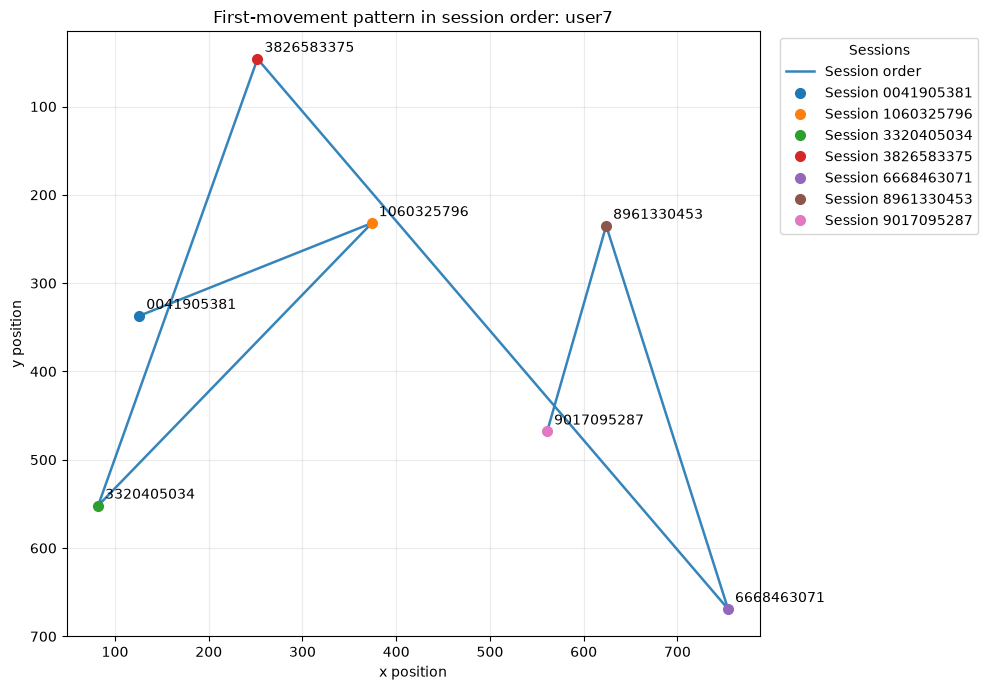

In [17]:
ordered_points = points.sort_values(
    "session_id",
    key=lambda values: values.str.replace("session_", "", regex=False).astype(int),
)

x_values = ordered_points["x"].tolist()
y_values = ordered_points["y"].tolist()
session_labels = ordered_points["session_id"].str.replace("session_", "", regex=False).tolist()

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(
    x_values,
    y_values,
    linewidth=1.8,
    color="tab:blue",
    alpha=0.9,
    label="Session order",
)

for x_value, y_value, session_label in zip(x_values, y_values, session_labels):
    ax.plot(
        x_value,
        y_value,
        marker="o",
        linestyle="None",
        markersize=7,
        label=f"Session {session_label}",
    )
    ax.annotate(session_label, (x_value, y_value), xytext=(5, 5), textcoords="offset points")

ax.set_title(f"First-movement pattern in session order: {USER_ID}")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.invert_yaxis()
ax.grid(alpha=0.25)
ax.legend(title="Sessions", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()